
# Economic Drivers of Homeownership Rates

### **By:** Kasey Savage  
### **Date:** May 9, 2025



## **Research Question**

**How do key macroeconomic indicators—such as GDP, inflation, mortgage rates, and unemployment—affect homeownership rates?



## **Introduction and Data Sources**

The data for this project comes from the **Federal Reserve Economic Data (FRED)**. I included:

- Real GDP (quarterly)
- Inflation (annual)
- Federal Debt as % of GDP
- Median Sales Price of Homes
- Unemployment Rate

## Data Loading and Cleaning

In [14]:
import pandas as pd

gdp = pd.read_csv('Real Gross Domestic Product, Billions of Chained 2017 Dollars, Quarterly, Seasonally Adjusted Annual Rate.xls - FRED Graph.csv', skiprows=10)
gdp.columns = ['DATE', 'GDP']
gdp['DATE'] = pd.to_datetime(gdp['DATE'])

inflation = pd.read_csv('Inflation, consumer prices for the United States, Percent, Annual, Not Seasonally Adjusted.xls - FRED Graph.csv', skiprows=10)
inflation.columns = ['DATE', 'inflation_rate']
inflation['DATE'] = pd.to_datetime(inflation['DATE'])

interest = pd.read_csv('FEDFUNDS.csv')
interest.columns = ['DATE', 'interest_rate']
interest['DATE'] = pd.to_datetime(interest['DATE'])

unemployment = pd.read_csv('UNRATE.csv')
unemployment.columns = ['DATE', 'unemployment_rate']
unemployment['DATE'] = pd.to_datetime(unemployment['DATE'])

house_price = pd.read_csv('MSPUS.csv')
house_price.columns = ['DATE', 'median_house_price']
house_price['DATE'] = pd.to_datetime(house_price['DATE'])


print(gdp.head())
print(inflation.head())
print(interest.head())
print(unemployment.head())
print(house_price.head())


        DATE       GDP
,0 1947-01-01  2182.681
,1 1947-04-01  2176.892
,2 1947-07-01  2172.432
,3 1947-10-01  2206.452
,4 1948-01-01  2239.682
,        DATE  inflation_rate
,0 1960-01-01        1.457976
,1 1961-01-01        1.070724
,2 1962-01-01        1.198773
,3 1963-01-01        1.239669
,4 1964-01-01        1.278912
,        DATE  interest_rate
,0 1954-07-01           0.80
,1 1954-08-01           1.22
,2 1954-09-01           1.07
,3 1954-10-01           0.85
,4 1954-11-01           0.83
,        DATE  unemployment_rate
,0 1948-01-01                3.4
,1 1948-02-01                3.8
,2 1948-03-01                4.0
,3 1948-04-01                3.9
,4 1948-05-01                3.5
,        DATE  median_house_price
,0 1963-01-01             17800.0
,1 1963-04-01             18000.0
,2 1963-07-01             17900.0
,3 1963-10-01             18500.0
,4 1964-01-01             18500.0


In [18]:
merged_df = gdp \
    .merge(inflation, on='DATE', how='inner') \
    .merge(interest, on='DATE', how='inner') \
    .merge(unemployment, on='DATE', how='inner') \
    .merge(house_price, on='DATE', how='inner')

print(merged_df)

         DATE        GDP  inflation_rate  interest_rate  unemployment_rate  \
,0  1963-01-01   3893.482        1.239669           2.92                5.7   
,1  1964-01-01   4135.553        1.278912           3.48                5.6   
,2  1965-01-01   4362.111        1.585169           3.90                4.9   
,3  1966-01-01   4731.888        3.015075           4.42                4.0   
,4  1967-01-01   4870.299        2.772786           4.94                3.9   
,..        ...        ...             ...            ...                ...   
,56 2019-01-01  20431.641        1.812210           2.40                4.0   
,57 2020-01-01  20693.238        1.233584           1.55                3.6   
,58 2021-01-01  21058.379        4.697859           0.09                6.4   
,59 2022-01-01  21903.850        8.002800           0.08                4.0   
,60 2023-01-01  22403.435        4.116338           4.33                3.4   
,
,    median_house_price  
,0              17800.0  

## Descriptive Statistical Analysis

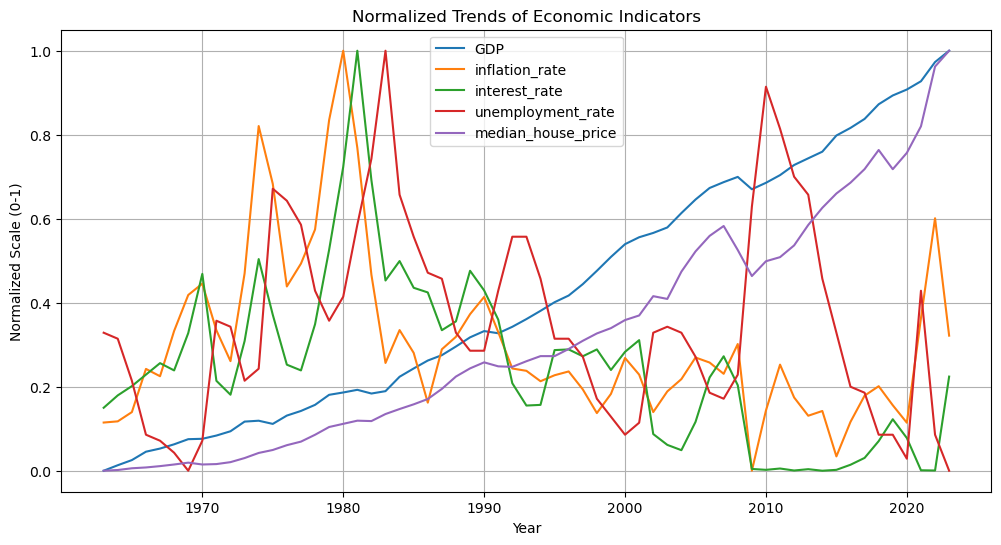

In [20]:
from sklearn.preprocessing import MinMaxScaler

scaled_data = merged_df.copy()
scaler = MinMaxScaler()
scaled_data[['GDP', 'inflation_rate', 'interest_rate', 'unemployment_rate', 'median_house_price']] = scaler.fit_transform(
    scaled_data[['GDP', 'inflation_rate', 'interest_rate', 'unemployment_rate', 'median_house_price']])

plt.figure(figsize=(12, 6))
for col in ['GDP', 'inflation_rate', 'interest_rate', 'unemployment_rate', 'median_house_price']:
    plt.plot(scaled_data['DATE'], scaled_data[col], label=col)

plt.legend()
plt.title("Normalized Trends of Economic Indicators")
plt.xlabel("Year")
plt.ylabel("Normalized Scale (0-1)")
plt.grid(True)
plt.show()

This chart shows the normalized trends of GDP, inflation, interest rates, unemployment rates, and median house prices in the U.S. from 1963 to 2023. By putting all variables on the same scale, we can clearly observe how these macroeconomic factors relate to the rise and fall of house prices over time. One key insight is that house prices closely follow the upward trajectory of GDP, suggesting that long-term economic growth supports higher home values. We also see that sharp spikes in interest rates and inflation during the 1970s and early 1980s coincided with slower growth in house prices, which implies that high borrowing costs and rising prices may have made homeownership less affordable. Also, unemployment spikes—notably around 2009 and 2020 were associated with flattening or delayed growth in home prices, which shows that job market instability can reduce buyers' ability to purchase homes. Interestingly, while house prices continued climbing after the 2010s, interest and inflation rates remained low for much of that period, likely contributing to cheaper mortgage financing and stronger housing demand. This trend reversed slightly after 2020, when inflation surged and interest rates rose, but house prices still grew—indicating a potential lag or resilience in housing demand despite tightening economic conditions.

In [24]:
import statsmodels.api as sm

X = merged_df[['GDP', 'inflation_rate', 'interest_rate', 'unemployment_rate']]
y = merged_df['median_house_price']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
,==============================================================================
,Dep. Variable:     median_house_price   R-squared:                       0.979
,Model:                            OLS   Adj. R-squared:                  0.978
,Method:                 Least Squares   F-statistic:                     655.2
,Date:                Fri, 09 May 2025   Prob (F-statistic):           2.69e-46
,Time:                        20:26:16   Log-Likelihood:                -676.56
,No. Observations:                  61   AIC:                             1363.
,Df Residuals:                      56   BIC:                             1374.
,Df Model:                           4                                         
,Covariance Type:            nonrobust                                         
,=====================================================================================
,                        coef    s

GDP is a strong predictor of median house prices. This is shown by its p-value of p < 0.001, which is statistically significant. This implies that economic growth supports demand. The coefficient 19.96 tells us that for every 1 billion dollar increase in real GDP, median house prices increase by about $19,962, holding other variables constant.

Inflation rate has a marginally significant relationship with house prices. This is shown by its p-value of approximately 0.052, which is just above the 0.05 threshold. This implies a borderline significant effect. Its coefficient of 2096.56 tells us that a 1% increase in inflation corresponds to an estimated $2,096 increase in median house prices.

Interest rate is not a statistically significant predictor of house prices. This is shown by its p-value of 0.50, suggesting that there is no meaningful relationship in this model. Its coefficient of -602.19 tells us that higher interest rates are associated with a small decrease in home prices, but this relationship is not statistically meaningful. This may be due to collinearity with other variables or because interest rate effects operate on a delayed timeline.

Unemployment rate is a statistically significant negative predictor of house prices. This is shown by its p-value of 0.028 which indicates that the relationship is significant at the 5% level. Its coefficient of -2969.04 implies that for every 1% increase in unemployment, median house prices decrease by approximately $2,969, which tells us that higher joblessness weakens housing demand. In other words, this suggests that labor market weakness negatively affects housing demand.

## Statistical Inference

In [27]:
import statsmodels.api as sm

X = merged_df[['GDP', 'inflation_rate', 'interest_rate', 'unemployment_rate']]
y = merged_df['median_house_price']

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
,==============================================================================
,Dep. Variable:     median_house_price   R-squared:                       0.979
,Model:                            OLS   Adj. R-squared:                  0.978
,Method:                 Least Squares   F-statistic:                     655.2
,Date:                Fri, 09 May 2025   Prob (F-statistic):           2.69e-46
,Time:                        20:41:46   Log-Likelihood:                -676.56
,No. Observations:                  61   AIC:                             1363.
,Df Residuals:                      56   BIC:                             1374.
,Df Model:                           4                                         
,Covariance Type:            nonrobust                                         
,=====================================================================================
,                        coef    s

With this regression, we get an R-squared of 0.979 which means that about 97.9% of the variation in median house prices is explained by the variables in my model: GDP, inflation, interest rate, and unemployment. This is extremely high and indicates a great fit for my model.
It shows that housing prices relation with GDP is statistically significant and the strongest predictor. For every 1 billion increase in GDP, median house prices go up by about 19,963, holding other variables constant. The inflation rates relation with housing prices is marginally significant. A 1 percent increase in inflation is associated with about a 2,097 increase in house prices. Since the p value is right above 5% we might cautiously say inflation impacts housing, but not strongly. Interest rates relationship with housing prices is not statistically significant and has a p-value of .5. This suggests that, at least in this model, interest rates don’t explain much variation in house prices, but with inflation you do have to take into account lag. The unemployment rate and housing prices have a statistically significant relationship, and it is negative. A 1% rise in unemployment leads to an estimated $2,969 drop in house prices, suggesting labor market weakness suppresses demand. The intercept is just the median house price if all predictors were 0. 

## Prediction Model using Regression:

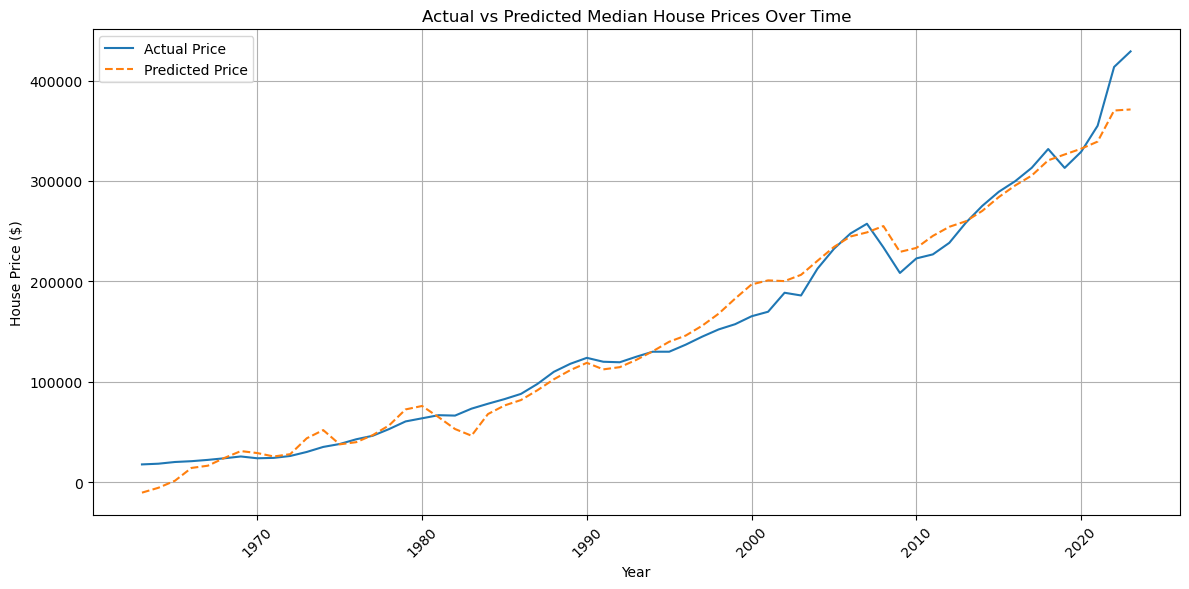

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

merged_df['predicted_price'] = model.predict(X)

plt.figure(figsize=(12, 6))
sns.lineplot(data=merged_df, x='DATE', y='median_house_price', label='Actual Price')
sns.lineplot(data=merged_df, x='DATE', y='predicted_price', label='Predicted Price', linestyle='--')
plt.title('Actual vs Predicted Median House Prices Over Time')
plt.xlabel('Year')
plt.ylabel('House Price ($)')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


## Conclusion



This analysis demonstrates that macroeconomic indicators—particularly GDP and unemployment—have a significant influence on median house prices in the United States. Among all predictors studied, GDP emerged as the most powerful driver, with a strong positive and statistically significant relationship to housing prices. This confirms the intuitive link between broad economic growth and household purchasing power, which in turn fuels housing demand. 

Unemployment rate was also a statistically significant predictor, but with a negative relationship, highlighting how labor market weakness can dampen housing activity. While 
inflation showed a marginally significant effect, its impact on home prices appears to be weaker and possibly subject to delayed or indirect mechanisms. Interest rates, somewhat 
surprisingly, were not a statistically significant predictor in this model, suggesting that either their effects are captured by other variables (like inflation), or that their influence operates on longer lags not captured here.

The regression model achieved an R-squared of 0.979, indicating that nearly 98% of the variation in house prices is explained by the selected variables. While this suggests excellent model fit, it also raises flags about possible multicollinearity—especially between GDP and other macro indicators. Future iterations could benefit from including lagged variables, regional breakdowns, or structural shifts in housing policy.

Ultimately, this analysis provides a data-driven foundation for understanding the economic forces that shape homeownership affordability and demand. It reinforces that strong job markets and robust GDP growth are key to sustained appreciation in housing prices, while inflation and interest rate effects are more complex and may require further time-series or causality analysis to fully untangle.


In [ ]:
!jupyter nbconvert --to markdown Homeownership_Disparities_Analysis (2)